## Detection of which members who weakening

In [7]:
#!/usr/bin/env python3
import os
import glob
import numpy as np
import xarray as xr
import re

# ============================================================
# SETTINGS
# ============================================================

# msftyz Oyear files for Atlantic
BASE = "/data/projects/nckf/frekle/CMIP6_data"

MODELS = {
    "EC-Earth3":    f"{BASE}/EC-Earth3/msftyz/Atl/msftyz_Oyear_EC-Earth3_historical_r*i1p1f1*_Atl.nc",
    "IPSL-CM6A-LR": f"{BASE}/IPSL-CM6A-LR/msftyz/Atl/msftyz_Oyear_IPSL-CM6A-LR_historical_r*i1p1f1*_Atl.nc",
}

OUT_PREFIX = "weakening_members"


# ============================================================
# Helper: extract member ID safely (regex)
# ============================================================
def extract_member_id(fname):
    """
    Extracts rXiYpZfW pattern from filename using regex.
    This works even if filename layout changes.
    """
    m = re.search(r"r[0-9]+i[0-9]+p[0-9]+f[0-9]+", fname)
    if m:
        return m.group(0)
    else:
        raise ValueError(f"Cannot find member ID in filename: {fname}")


# ============================================================
# Helper: compute AMOC index
# ============================================================
def compute_amoc_index(ds):
    """
    Extracts an AMOC index regardless of grid type.
    Works for EC-Earth3, CESM2, IPSL.
    """

    msf = ds["msftyz"]

    dims = msf.dims

    # ---- depth coordinate ----
    depth_dim = None
    for cand in ["lev", "olevel", "depth"]:
        if cand in dims:
            depth_dim = cand
            break

    # ---- latitude dims ----
    lat_dims = []
    for cand in ["rlat", "lat", "y", "j"]:
        if cand in dims:
            lat_dims.append(cand)

    # ---- longitude dims ----
    lon_dims = []
    for cand in ["lon", "x", "i"]:
        if cand in dims:
            lon_dims.append(cand)

    # ---- Select depth range 500–2000 m if possible ----
    if depth_dim is not None:
        if depth_dim in ds:
            lev_mask = (ds[depth_dim] >= 500) & (ds[depth_dim] <= 2000)
            msf = msf.sel({depth_dim: lev_mask})
        # else: leave as is

    # ---- Collapse over spatial dims ----
    collapse_dims = []
    if depth_dim: collapse_dims.append(depth_dim)
    collapse_dims += lat_dims
    collapse_dims += lon_dims

    # Remove time from collapse dims
    collapse_dims = [d for d in collapse_dims if d != "time"]

    # Compute AMOC index as maximum over these dims
    amoc = msf.max(dim=collapse_dims)

    return amoc



# ============================================================
# MAIN LOOP OVER MODELS
# ============================================================

for model, pattern in MODELS.items():

    print(f"\n==============================================")
    print(f"🔍 Checking AMOC weakening for model: {model}")
    print(f"==============================================")

    files = sorted(glob.glob(pattern))

    if len(files) == 0:
        print(f"⚠️  No files found for {model}! Check paths.")
        continue

    weakening_members = []

    for f in files:
        fname = os.path.basename(f)
        print(f"\n→ Loading {fname}")

        # Extract rXiYiZiW
        member = extract_member_id(fname)
        print(f"   Member detected: {member}")

        ds = xr.open_dataset(f)

        # Compute AMOC index
        amoc = compute_amoc_index(ds)
        t = np.arange(amoc.size)

        # Linear trend
        slope = np.polyfit(t, amoc.values, 1)[0]
        print(f"   AMOC trend: {slope:.4e}")

        # Negative trend = weakening
        if slope < 0:
            print(f"   → Member {member} shows AMOC weakening")
            weakening_members.append(member)
        else:
            print(f"   → Member {member} does NOT weaken")

    print("\n📉 Weakening members for", model)
    print("   ", weakening_members)

    # Save results
    outname = f"{OUT_PREFIX}_{model}.txt"
    with open(outname, "w") as fout:
        for m in weakening_members:
            fout.write(m + "\n")

    print(f"💾 Saved weakening member list to: {outname}\n")



🔍 Checking AMOC weakening for model: EC-Earth3

→ Loading msftyz_Oyear_EC-Earth3_historical_r10i1p1f1_gn_185001-201412_Atl.nc
   Member detected: r10i1p1f1
   AMOC trend: 1.0382e+07
   → Member r10i1p1f1 does NOT weaken

→ Loading msftyz_Oyear_EC-Earth3_historical_r11i1p1f1_gn_185001-201412_Atl.nc
   Member detected: r11i1p1f1
   AMOC trend: -1.1922e+07
   → Member r11i1p1f1 shows AMOC weakening

→ Loading msftyz_Oyear_EC-Earth3_historical_r12i1p1f1_gn_185001-201412_Atl.nc
   Member detected: r12i1p1f1
   AMOC trend: 2.0310e+07
   → Member r12i1p1f1 does NOT weaken

→ Loading msftyz_Oyear_EC-Earth3_historical_r13i1p1f1_gn_185001-201412_Atl.nc
   Member detected: r13i1p1f1
   AMOC trend: 1.7591e+07
   → Member r13i1p1f1 does NOT weaken

→ Loading msftyz_Oyear_EC-Earth3_historical_r14i1p1f1_gn_185001-201412_Atl.nc
   Member detected: r14i1p1f1
   AMOC trend: 7.5275e+04
   → Member r14i1p1f1 does NOT weaken

→ Loading msftyz_Oyear_EC-Earth3_historical_r15i1p1f1_gn_185001-201412_Atl.nc
  

### EOf analysis only on weakening members

In [2]:
#!/usr/bin/env python3
# ============================================================
# Combined EOF Analysis for CMIP6 ocean temperature
# Only uses weakening members per model (OPTION A)
# ============================================================

import os
import glob
import re
import numpy as np
import xarray as xr
from eofs.standard import Eof
import warnings
warnings.filterwarnings("ignore")

# ============================
# CONFIG
# ============================

MODEL   = "EC-Earth3"       # ← CHANGE THIS ONLY
VAR     = "thetao"
NMODES  = 50

IN_DIR  = f"/data/projects/nckf/frekle/CMIP6_data/{MODEL}/{VAR}/"
OUT_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined/"
os.makedirs(OUT_DIR, exist_ok=True)

START_YEAR = 1850
END_YEAR   = 2014

# ============================================================
# ✅ WEAKENING MEMBERS PER MODEL  (OPTION A)
# ============================================================

WEAKENING = {
    "EC-Earth3": [
        "r11i1p1f1", "r19i1p1f1", "r1i1p1f1", "r24i1p1f1", "r7i1p1f1", "r8i1p1f1"
    ],

    "IPSL-CM6A-LR": [
        "r11i1p1f1", "r13i1p1f1", "r16i1p1f1", "r20i1p1f1", "r27i1p1f1", "r6i1p1f1", "r8i1p1f1"
    ]
}

# Select the right list for this run
WEAKENING_MEMBERS = WEAKENING.get(MODEL, [])
if len(WEAKENING_MEMBERS) == 0:
    raise ValueError(f"No weakening members defined for MODEL={MODEL}")


# ============================================================
# Helper: standard grid normalization
# ============================================================

def standardize_latlon(ds):
    lat_var = next((v for v in ["lat","latitude","nav_lat"] if v in ds), None)
    lon_var = next((v for v in ["lon","longitude","nav_lon"] if v in ds), None)
    if lat_var is None or lon_var is None:
        raise KeyError("lat/lon not found")

    lat = ds[lat_var]
    lon = ds[lon_var]

    # Regular grid
    if lat.ndim == 1 and lon.ndim == 1:
        print("   → Regular grid (1D lat/lon)")
        lon2d, lat2d = np.meshgrid(lon.values, lat.values)
        ds2 = ds.drop_vars([lat_var, lon_var])
        ds2 = ds2.rename_dims({lat.dims[0]: "y", lon.dims[0]: "x"})
        ds2["lat"] = xr.DataArray(lat2d, dims=("y","x"))
        ds2["lon"] = xr.DataArray(lon2d, dims=("y","x"))
        return ds2, ("y","x")

    # Curvilinear grid
    if lat.ndim == 2:
        print("   → Curvilinear grid (2D lat/lon)")
        ydim, xdim = lat.dims
        ds2 = ds.swap_dims({ydim: "y", xdim: "x"})
        ds2 = ds2.rename({lat_var: "lat", lon_var: "lon"})
        for bad in ["x","y"]:
            if bad in ds2 and bad not in ["lat","lon"]:
                try: ds2 = ds2.drop_vars(bad)
                except: pass
        return ds2, ("y","x")

    raise ValueError("Unsupported grid format")


# ============================================================
# Member ID extraction
# ============================================================

def parse_member_label(path):
    base = os.path.basename(path)
    m = re.search(r"(r\d+i\d+p\d+f\d+)", base)
    return m.group(1) if m else None


# ============================================================
# 1. FIND ONLY FILES FROM WEAKENING MEMBERS
# ============================================================

all_files = sorted(glob.glob(os.path.join(IN_DIR, f"{VAR}_masked_r*i*p*f*.nc")))
files = []

for f in all_files:
    label = parse_member_label(f)
    if label in WEAKENING_MEMBERS:
        files.append(f)

print("\n📌 Using ONLY these weakening members:")
for f in files:
    print("   →", os.path.basename(f))

if len(files) == 0:
    raise ValueError("No weakening members found!")


# ============================================================
# 2. PROCESS MEMBERS (your original workflow)
# ============================================================

anom_list = []
member_labels = []
lat2d = lon2d = None

for idx, f in enumerate(files, start=1):
    label = parse_member_label(f)
    member_labels.append(label)

    print(f"\n→ Loading member {idx}/{len(files)}: {label}")

    ds = xr.open_dataset(f)
    ds, _ = standardize_latlon(ds)

    if lat2d is None:
        lat2d = ds["lat"]
        lon2d = ds["lon"]

    da = ds[VAR]

    if "lev" in da.dims or "olevel" in da.dims:
        da = da.isel({d: 0 for d in da.dims if d in ["lev","olevel"]})

    yrs = da["time"].dt.year
    da = da.sel(time=slice(f"{START_YEAR}-01-01", f"{END_YEAR}-12-31"))

    anom = da - da.mean("time")
    anom = anom.expand_dims(member=[label])
    anom_list.append(anom)


# ============================================================
# 3. ALIGN TIME ACROSS MEMBERS
# ============================================================

print("\n🧭 Aligning time axis…")

common_time = anom_list[0]["time"].values
for a in anom_list[1:]:
    common_time = np.intersect1d(common_time, a["time"].values)

common_time = xr.DataArray(common_time, dims=("time",))
aligned = [a.sel(time=common_time) for a in anom_list]
combined = xr.concat(aligned, dim="member")

n_member = combined.sizes["member"]
n_time   = combined.sizes["time"]
ny, nx   = combined.sizes["y"], combined.sizes["x"]

print(f"   → Final: members={n_member}, time={n_time}, grid={ny}×{nx}")

# ============================================================
# 4. PREPARE FOR EOF
# ============================================================

data2d = combined.values.reshape(n_member*n_time, ny*nx)
data2d = np.ma.masked_invalid(data2d)

ref = xr.open_dataset(files[0])
if "areacello" in ref:
    area = ref["areacello"]
    if area.ndim == 2:
        w = np.sqrt(area.values.reshape(ny*nx))
    else:
        w = np.sqrt(np.cos(np.deg2rad(lat2d.values)).reshape(ny*nx))
else:
    w = np.sqrt(np.cos(np.deg2rad(lat2d.values)).reshape(ny*nx))

print("\n🚀 Running EOF…")
solver = Eof(data2d, weights=w)

EOFs = solver.eofs(neofs=NMODES).reshape(NMODES, ny, nx)
PCs  = solver.pcs(npcs=NMODES).reshape(n_member, n_time, NMODES)
VF   = solver.varianceFraction()[:NMODES]

# ============================================================
# 5. SAVE RESULTS
# ============================================================

outfile = os.path.join(OUT_DIR, f"EOF_combined_{VAR}_WEAKENING_ONLY.nc")

print("\n💾 Saving:", outfile)

ds_out = xr.Dataset(
    {
        "EOF": (("mode","y","x"), EOFs),
        "PC":  (("member","time","mode"), PCs),
        "variance_fraction": (("mode",), VF),
    },
    coords={
        "mode": np.arange(1, NMODES+1),
        "member": np.array(member_labels, dtype=str),
        "time": common_time,
        "lat": lat2d,
        "lon": lon2d,
    }
)

ds_out.to_netcdf(outfile)
print("\n🎉 DONE — weakening-only combined EOF created.\n")



📌 Using ONLY these weakening members:
   → thetao_masked_r11i1p1f1.nc
   → thetao_masked_r19i1p1f1.nc
   → thetao_masked_r1i1p1f1.nc
   → thetao_masked_r24i1p1f1.nc
   → thetao_masked_r7i1p1f1.nc
   → thetao_masked_r8i1p1f1.nc

→ Loading member 1/6: r11i1p1f1
   → Curvilinear grid (2D lat/lon)

→ Loading member 2/6: r19i1p1f1
   → Curvilinear grid (2D lat/lon)

→ Loading member 3/6: r1i1p1f1
   → Curvilinear grid (2D lat/lon)

→ Loading member 4/6: r24i1p1f1
   → Curvilinear grid (2D lat/lon)

→ Loading member 5/6: r7i1p1f1
   → Curvilinear grid (2D lat/lon)

→ Loading member 6/6: r8i1p1f1
   → Curvilinear grid (2D lat/lon)

🧭 Aligning time axis…
   → Final: members=6, time=165, grid=292×362

🚀 Running EOF…

💾 Saving: /data/projects/nckf/frekle/EOF_results/EC-Earth3/combined/EOF_combined_thetao_WEAKENING_ONLY.nc

🎉 DONE — weakening-only combined EOF created.



## Plots


📘 Plotting EOF + PC for EC-Earth3
💾 Saved: /data/projects/nckf/frekle/EOF_plots/EC-Earth3_EOF_PC_first3_WEAKENING_ONLY.png


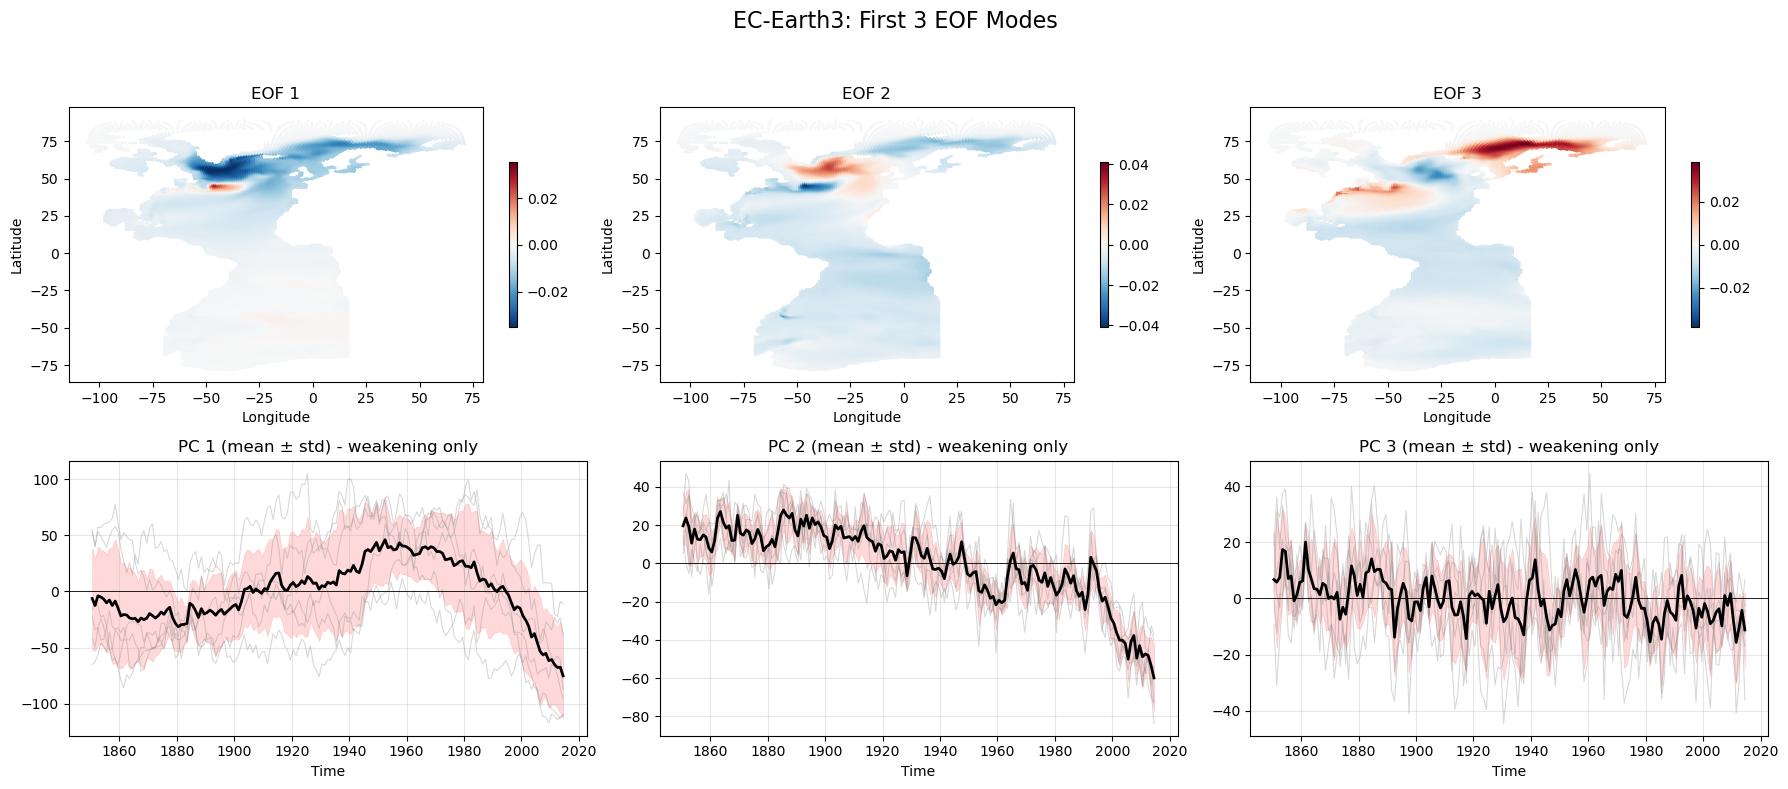


📘 Plotting EOF + PC for IPSL-CM6A-LR
💾 Saved: /data/projects/nckf/frekle/EOF_plots/IPSL-CM6A-LR_EOF_PC_first3_WEAKENING_ONLY.png


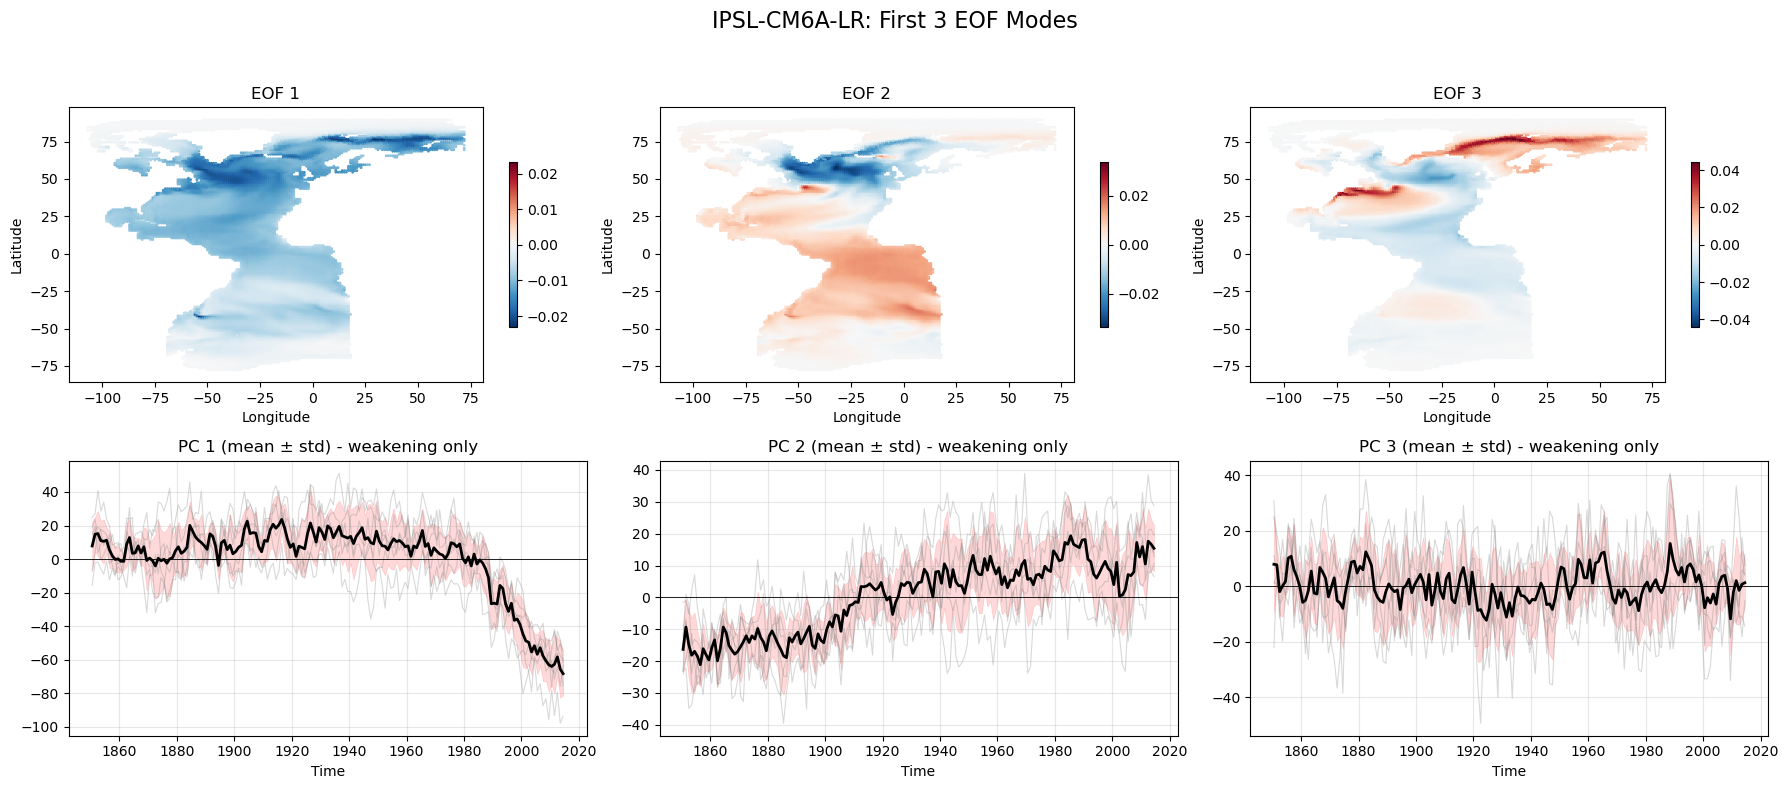


🎉 All model plots complete!



In [3]:
#!/usr/bin/env python3
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================
# SETTINGS
# ============================================
MODELS = ["EC-Earth3", "IPSL-CM6A-LR"]
VAR    = "thetao"
EOF_DIR = "/data/projects/nckf/frekle/EOF_results"
OUT_DIR = "/data/projects/nckf/frekle/EOF_plots"
os.makedirs(OUT_DIR, exist_ok=True)

NMODES = 3   # plot EOF/PC modes 1–3


# ============================================
# Helper: symmetric color range
# ============================================
def symmetric_clim(field):
    vmax = np.nanmax(np.abs(field))
    return -vmax, vmax


# ============================================
# Helper: Native-grid scatter-method EOF plotting
# (works for 1D, 2D, and curvilinear grids)
# ============================================
def plot_eof_native(ax, lat, lon, eof_field, mode):
    lon2 = ((lon + 180) % 360) - 180   # wrap longitude to [-180,180]

    vmin, vmax = symmetric_clim(eof_field)

    sc = ax.scatter(
        lon2.values, lat.values,
        c=eof_field.values,
        s=1.0,
        cmap="RdBu_r",
        vmin=vmin, vmax=vmax,
    )

    ax.set_title(f"EOF {mode+1}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(sc, ax=ax, shrink=0.6)


# ============================================
# MAIN LOOP OVER MODELS
# ============================================
for model in MODELS:

    print(f"\n📘 Plotting EOF + PC for {model}")

    # --- load file ---
    f = f"{EOF_DIR}/{model}/combined/EOF_combined_{VAR}_WEAKENING_ONLY.nc"
    ds = xr.open_dataset(f)

    EOF = ds["EOF"]         # (mode, y, x)
    PC  = ds["PC"]          # (member, time, mode)
    lat = ds["lat"]         # (y, x)
    lon = ds["lon"]         # (y, x)

    # ============================================
    # FIX TIME AXIS (CESM uses cftime)
    # ============================================
    if not np.issubdtype(ds["time"].dtype, np.datetime64):
        print(f"   → Converting cftime → datetime64 for {model}")
        try:
            time_np = ds.indexes["time"].to_datetimeindex()
        except Exception:
            # fallback: convert to strings, then to datetime
            time_np = ds["time"].dt.strftime("%Y-%m-%d").astype("datetime64[ns]")
    else:
        time_np = ds["time"].values

    # ============================================
    # CREATE FIGURE
    # ============================================
    fig, axes = plt.subplots(2, NMODES, figsize=(18, 8))
    fig.suptitle(f"{model}: First 3 EOF Modes", fontsize=16)

    # ============================
    # 1. EOF Spatial Maps
    # ============================
    for m in range(NMODES):
        field = EOF.isel(mode=m)
        plot_eof_native(axes[0, m], lat, lon, field, m)

    # ============================
    # 2. PC Timeseries
    # ============================
    for m in range(NMODES):
        ax = axes[1, m]

        pcs_all  = PC.isel(mode=m)        # (member, time)
        pcs_mean = pcs_all.mean("member") # (time)
        pcs_std  = pcs_all.std("member")  # (time)

        # ---- plot each member ----
        for mem in range(pcs_all.sizes["member"]):
            ax.plot(
                time_np,
                pcs_all.isel(member=mem),
                color="gray",
                alpha=0.3,
                lw=0.8
            )

        # ---- mean line ----
        ax.plot(
            time_np, pcs_mean,
            color="black",
            lw=2,
            label="Mean"
        )

        # ---- ± std shading ----
                # thin red standard deviation band
        ax.fill_between(
            time_np,
            pcs_mean - pcs_std,
            pcs_mean + pcs_std,
            color="red",
            alpha=0.15,         # thin transparent band
            edgecolor="red",
            linewidth=0.5,
            label="±1 std"
        )


        ax.axhline(0, color="black", lw=0.6)
        ax.grid(alpha=0.3)
        ax.set_title(f"PC {m+1} (mean ± std) - weakening only")
        ax.set_xlabel("Time")

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    outfile = f"{OUT_DIR}/{model}_EOF_PC_first3_WEAKENING_ONLY.png"
    fig.savefig(outfile, dpi=150)
    print(f"💾 Saved: {outfile}")

    plt.show()

print("\n🎉 All model plots complete!\n")
